# SuperMarket Sales - End-to-End Data Science Project

## Project Overview

This project performs an end-to-end Data Science workflow on supermarket
sales data. The project includes data cleaning, exploratory data analysis,
visualization, machine learning, model evaluation, and business insights.

## Objectives

- Understand the supermarket dataset
- Clean and preprocess the data
- Perform exploratory data analysis
- Generate meaningful visualizations
- Build a Machine Learning model
- Evaluate model performance
- Generate useful business insights

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
df = pd.read_csv("SuperMarket Analysis.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [16]:
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [17]:
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,1:28:00 PM,Cash,618.38,4.761905,30.9190,6.6


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [19]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [20]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [21]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [22]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1000, 17)


In [23]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [24]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Date', 'Time', 'Payment']


In [25]:
total_sales = df["Sales"].sum()

print("Total Sales:", round(total_sales, 2))

Total Sales: 322966.75


In [26]:
total_income = df["gross income"].sum()

print("Total Gross Income:", round(total_income, 2))

Total Gross Income: 15379.37


In [27]:
product_sales = (
    df.groupby("Product line")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


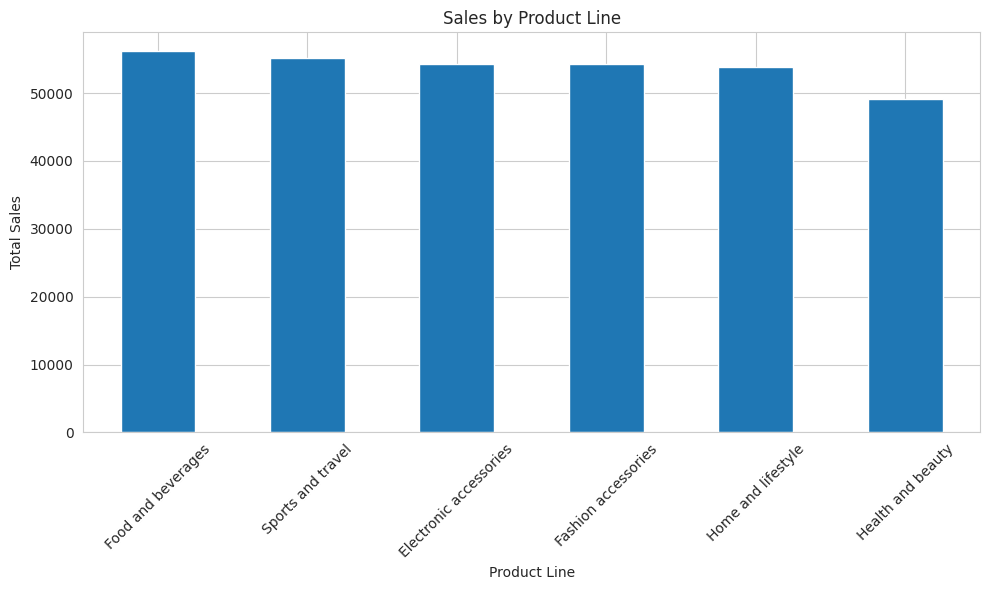

In [28]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
branch_sales = (
    df.groupby("Branch")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

branch_sales

,Sales
Branch,
Giza,110568.7065
Alex,106200.3705
Cairo,106197.6720


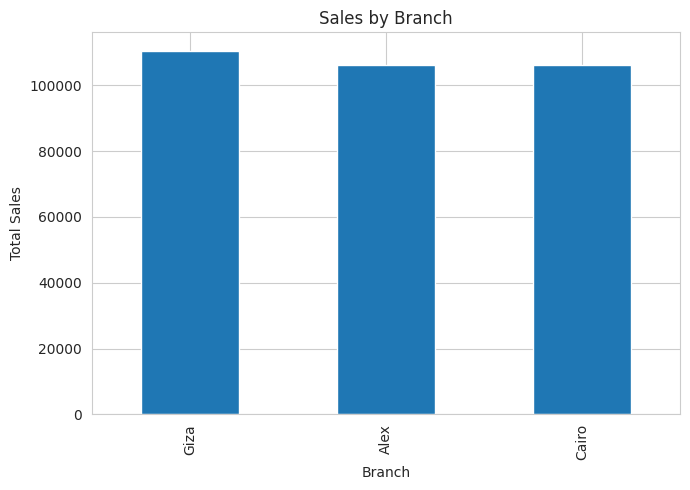

In [30]:
plt.figure(figsize=(7, 5))

branch_sales.plot(kind="bar")

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [31]:
payment_counts = df["Payment"].value_counts()

payment_counts

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


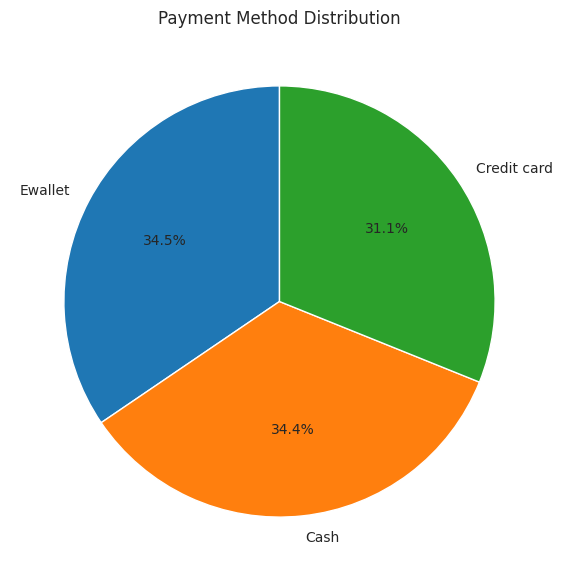

In [32]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.show()

In [33]:
average_rating = df["Rating"].mean()

print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 6.97


In [34]:
rating_by_product = (
    df.groupby("Product line")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

rating_by_product

,Rating
Product line,
Food and beverages,7.113218
Fashion accessories,7.029213
Health and beauty,7.003289
Electronic accessories,6.924706
Sports and travel,6.916265
Home and lifestyle,6.837500


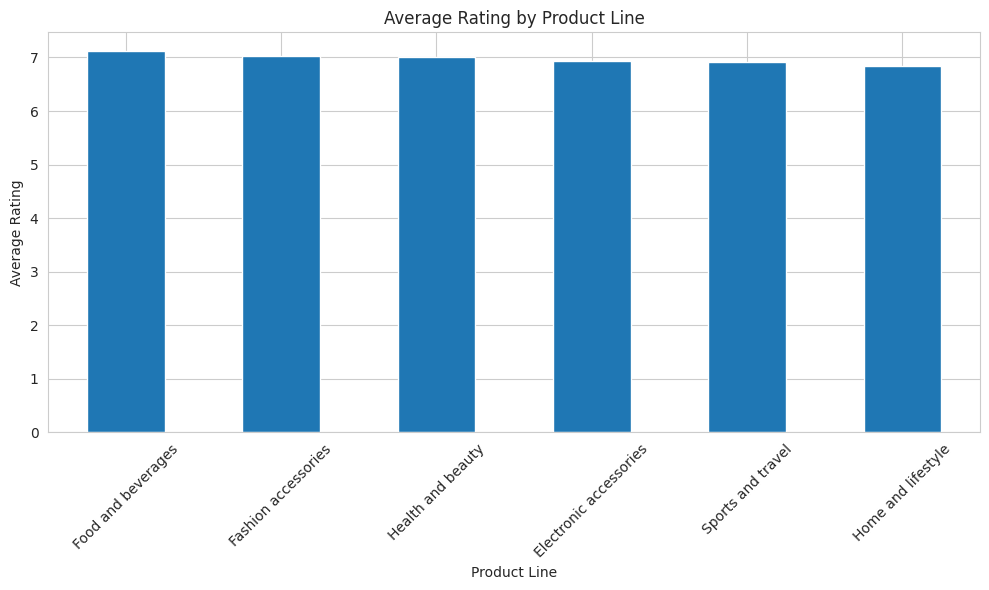

In [35]:
plt.figure(figsize=(10, 6))

rating_by_product.plot(kind="bar")

plt.title("Average Rating by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
numeric_columns = [
    "Unit price",
    "Quantity",
    "Tax 5%",
    "Sales",
    "cogs",
    "gross margin percentage",
    "gross income",
    "Rating"
]

correlation = df[numeric_columns].corr()

correlation

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
Unit price,1.000000,0.010778,0.633962,0.633962,0.633962,NaN,0.633962,-0.008778
Quantity,0.010778,1.000000,0.705510,0.705510,0.705510,NaN,0.705510,-0.015815
Tax 5%,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Sales,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000


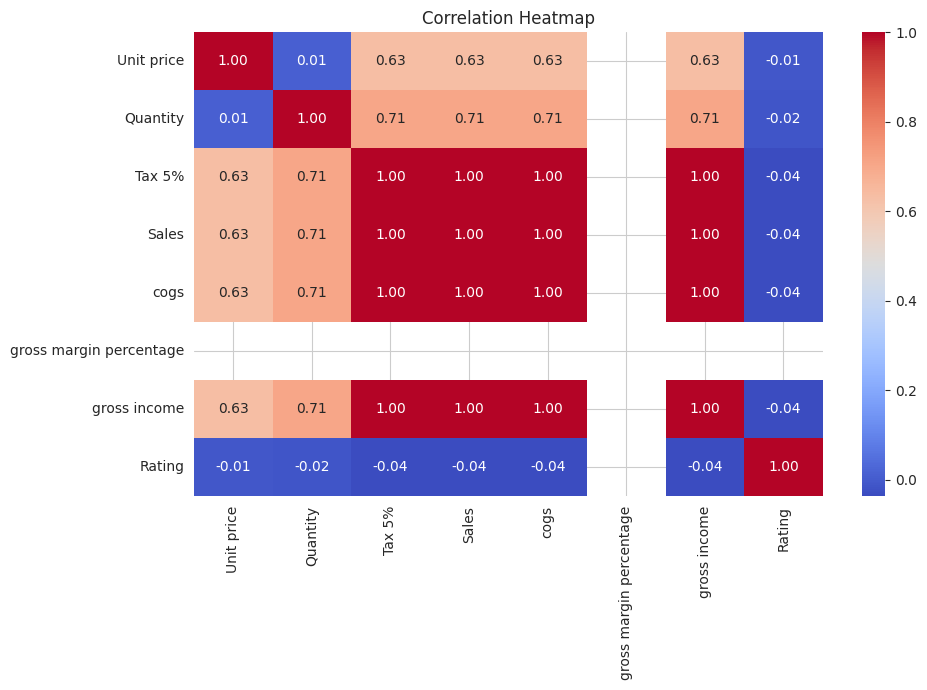

In [37]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Machine Learning

## Problem Statement

The objective is to build a Machine Learning model that predicts
supermarket sales using available transaction-level information.

## Target Variable

Sales

## Model

Random Forest Regressor

In [38]:
features = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Unit price",
    "Quantity",
    "Payment",
    "Rating"
]

X = df[features]
y = df["Sales"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 9)
Target: (1000,)


In [39]:
categorical_features = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Payment"
]

numerical_features = [
    "Unit price",
    "Quantity",
    "Rating"
]

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 9)
Testing data: (200, 9)


In [42]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [43]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [44]:
pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [45]:
y_pred = pipeline.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [46]:
prediction_comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

prediction_comparison.head(10)

,Actual Sales,Predicted Sales
0,523.9710,528.462742
1,616.9800,574.394992
2,408.7335,407.308335
3,135.3555,140.009572
4,45.9270,48.390458
5,618.9750,582.738870
6,127.8270,125.785905
7,731.6925,712.974570
8,450.1035,455.465168
9,138.1275,129.411240


In [47]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error: 6.03
Mean Squared Error: 86.55
Root Mean Squared Error: 9.3
R² Score: 0.9987


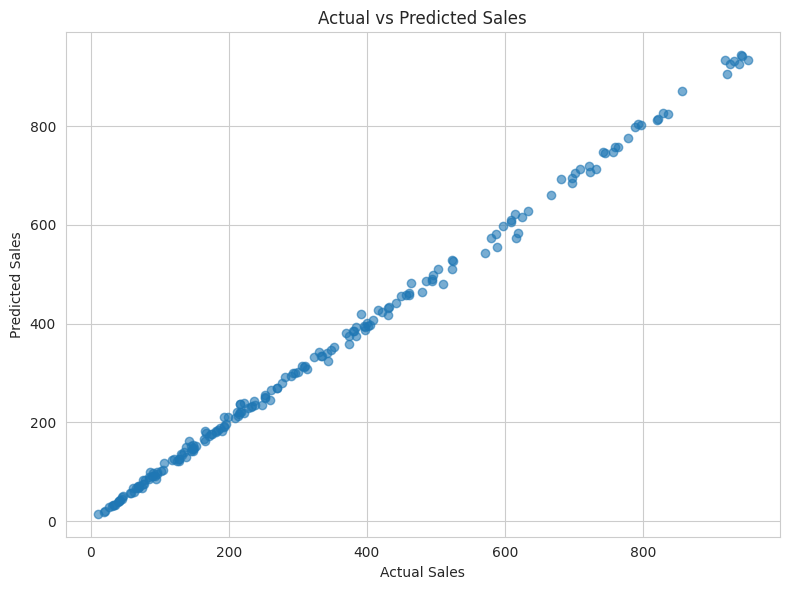

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.show()

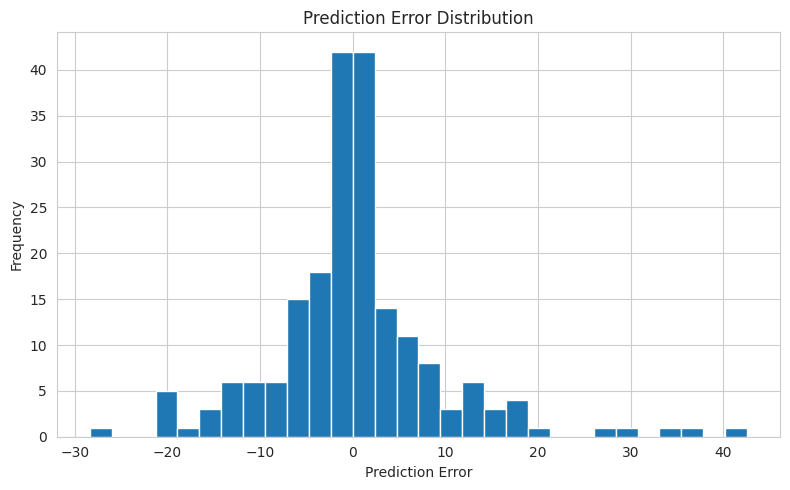

In [49]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Key Insights

## Data Analysis Insights

- The dataset contains supermarket transaction records across multiple branches.
- Product-line analysis shows differences in sales performance across categories.
- Branch-level analysis helps identify differences in revenue generation.
- Customers use multiple payment methods for their purchases.
- Customer ratings provide an indication of satisfaction across product categories.
- Gross income varies across product lines and transaction characteristics.

## Machine Learning Insights

- A Random Forest Regression model was developed to predict supermarket sales.
- The dataset was divided into training and testing sets.
- Categorical variables were converted using One-Hot Encoding.
- Model performance was evaluated using MAE, RMSE, and R².
- Actual and predicted sales were compared using visualization.

## Business Value

The analysis can help supermarket management understand sales patterns,
customer behavior, product performance, and factors associated with sales.
Machine Learning can further support sales prediction and data-driven
decision making.

# Conclusion

This project successfully completed an end-to-end Data Science workflow
using supermarket transaction data.

The project covered data loading, data cleaning, exploratory data analysis,
visualization, feature preprocessing, Machine Learning model development,
prediction, and model evaluation.

A Random Forest Regression model was used to predict sales, and its
performance was evaluated using MAE, RMSE, and R² score.

This project demonstrates practical skills in Python, Pandas, NumPy,
Matplotlib, Seaborn, and Scikit-learn and can be included as a
portfolio project.